#### Import Libraries

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

#### Download Stock Data

In [ ]:
# Download historical data
data = yf.download("AAPL", start="2020-01-01", end="2025-01-01")
# Display first rows
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400551,72.460814,71.156712,71.409815,135480400
2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928032,72.533072,71.708672,72.277555,108872000
2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200


#### Create Target (Next Day Close)

In [4]:
# Create target column (next day's closing price)
data['Next_Close'] = data['Close'].shift(-1)

# Remove last row (NaN value)
data = data.dropna()

#### Select Features and Target

In [5]:
X = data[['Open', 'High', 'Low', 'Volume']]
y = data['Next_Close']

#### Split Data (Train & Test)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

#### Train Linear Regression Model

In [7]:
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
#### Make Predictions

In [8]:
y_pred = model.predict(X_test)

#### Evaluate Model

In [9]:
print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.9852342957685587
Mean Absolute Error: 2.334059973420089


#### Plot Actual vs Predicted

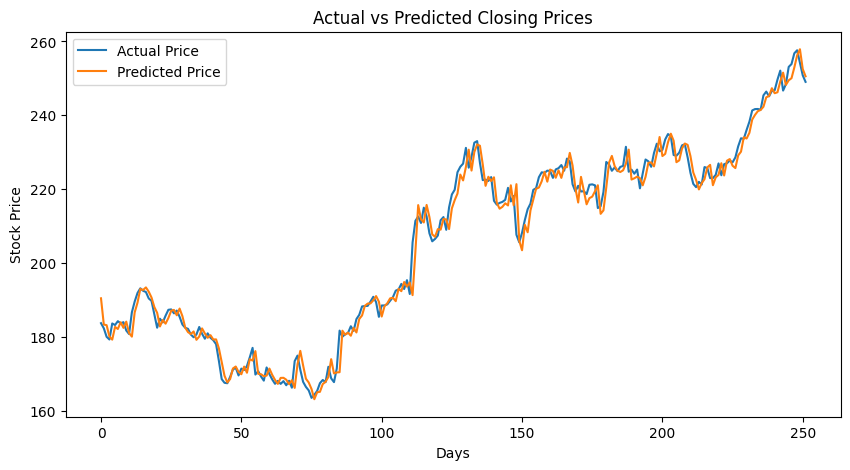

In [10]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')
plt.title("Actual vs Predicted Closing Prices")
plt.xlabel("Days")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

#### Predict Tomorrow’s Price

In [11]:
# Take last available data
last_data = X.tail(1)

# Predict next day closing price
next_day_price = model.predict(last_data)

print("Predicted Next Day Close Price:", next_day_price[0])

Predicted Next Day Close Price: 250.56928675948504


#### Save Dataset 

In [12]:
data.to_csv("AAPL_stock_data.csv")